# Differential Privacy Analysis with NoisyValue

This notebook demonstrates how to use `NoisyValue` to track noise and uncertainty in differentially private data analysis. We'll work through a realistic example: analyzing sensitive count data (like survey responses) while preserving privacy through noise addition.

## Setup: Import Libraries

In [ ]:
import sys
sys.path.insert(0, '/home/sbaldasty/code/github/sbaldasty/noisy-values')

import numpy as np
import matplotlib.pyplot as plt
from sympy.stats import Normal
from main import NoisyValue

# Set random seed for reproducibility
np.random.seed(42)

## Creating Sensitive Count Data

Imagine we have sensitive survey data - for example, counts of responses in various categories. We'll create a realistic dataset and then apply differential privacy noise.

In [2]:
# Create synthetic sensitive count data
# Let's say these are counts from different regions/groups
true_counts = np.array([150, 245, 87, 312, 156, 203, 89, 178])
region_names = ['Region A', 'Region B', 'Region C', 'Region D', 'Region E', 'Region F', 'Region G', 'Region H']

print("True (sensitive) counts:")
for name, count in zip(region_names, true_counts):
    print(f"  {name}: {count}")
    
print(f"\nTrue total: {true_counts.sum()}")
print(f"True mean: {true_counts.mean():.2f}")
print(f"True median: {np.median(true_counts):.2f}")

True (sensitive) counts:
  Region A: 150
  Region B: 245
  Region C: 87
  Region D: 312
  Region E: 156
  Region F: 203
  Region G: 89
  Region H: 178

True total: 1420
True mean: 177.50
True median: 167.00


## Applying Differential Privacy Noise

We apply Gaussian noise to each count to achieve differential privacy. The noise scale (epsilon) controls the privacy-utility tradeoff: smaller noise scale = better privacy, larger noise scale = better utility but less privacy.

In [ ]:
# Privacy parameter: how much noise to add
# Smaller scale = stronger privacy, larger scale = better accuracy
noise_scale = 10.0

# Create NoisyValue objects for each count
# We use Gaussian noise (standard approach in differential privacy)
noisy_counts = []
for i, true_count in enumerate(true_counts):
    noisy_val = NoisyValue.from_distribution(
        true_count, 
        Normal,
        0,  # mean of noise = 0
        noise_scale,  # standard deviation of noise
        provenance=f"count_{i}"
    )
    noisy_counts.append(noisy_val)
    
print(f"Created {len(noisy_counts)} noisy count values with noise scale σ = {noise_scale}")
print(f"\nFirst noisy value:")
print(f"  Observed (one realization): {noisy_counts[0].observed}")
print(f"  Symbolic expression: {noisy_counts[0].expr}")
print(f"  Latent symbols: {noisy_counts[0].thetas}")

Created 8 noisy count values with noise scale σ = 10.0

First noisy value:
  Observed (one realization): 149.7467394740089
  Symbolic expression: theta_count_0_0 + R0
  Latent symbols: {theta_count_0_0}


## Observing the Noisy Data

The `observed` values represent what we see in our dataset after noise addition. These are the values we'll analyze.

In [4]:
# Extract observed values
observed_counts = np.array([nv.observed for nv in noisy_counts])

print("Observed (noisy) counts:")
print(f"{'Region':<12} {'True':<8} {'Observed':<12} {'Difference':<12}")
print("-" * 44)
for name, true, obs in zip(region_names, true_counts, observed_counts):
    diff = obs - true
    print(f"{name:<12} {true:<8.0f} {obs:<12.2f} {diff:<12.2f}")

print(f"\nObserved total: {observed_counts.sum():.2f}")
print(f"Observed mean: {observed_counts.mean():.2f}")
print(f"Observed median: {np.median(observed_counts):.2f}")
print(f"\nMean error: {(observed_counts - true_counts).mean():.2f}")
print(f"RMS error: {np.sqrt(((observed_counts - true_counts) ** 2).mean()):.2f}")

Observed (noisy) counts:
Region       True     Observed     Difference  
--------------------------------------------
Region A     150      149.75       -0.25       
Region B     245      226.80       -18.20      
Region C     87       81.36        -5.64       
Region D     312      301.69       -10.31      
Region E     156      149.58       -6.42       
Region F     203      196.47       -6.53       
Region G     89       97.70        8.70        
Region H     178      179.29       1.29        

Observed total: 1382.63
Observed mean: 172.83
Observed median: 164.52

Mean error: -4.67
RMS error: 8.88


## Computing Aggregated Statistics

A key feature of `NoisyValue` is that noise propagates correctly through arithmetic operations. When we compute the total count, the uncertainty compounds appropriately.

In [5]:
# Compute total count using NoisyValue - noise propagates correctly!
total_noisy = sum(noisy_counts)  # Combines all counts, uncertainty compounds

print(f"Computing total by adding all noisy counts:")
print(f"  Observed total: {total_noisy.observed:.2f}")
print(f"  True total: {true_counts.sum()}")
print(f"  Error: {total_noisy.observed - true_counts.sum():.2f}")

# Compute mean using aggregation
mean_noisy = sum(noisy_counts) / len(noisy_counts)
print(f"\nComputing mean:")
print(f"  Observed mean: {mean_noisy.observed:.2f}")
print(f"  True mean: {true_counts.mean():.2f}")
print(f"  Error: {mean_noisy.observed - true_counts.mean():.2f}")

Computing total by adding all noisy counts:
  Observed total: 1382.63
  True total: 1420
  Error: -37.37

Computing mean:
  Observed mean: 172.83
  True mean: 177.50
  Error: -4.67


## Sampling to Quantify Uncertainty

`NoisyValue` lets us sample from the posterior distribution, accounting for all sources of uncertainty. This gives us a full picture of what values are compatible with our observation.

In [6]:
# Sample from the posterior distribution of the total
n_samples = 10000
total_samples = total_noisy.sample_n(n_samples, seed=123)

print(f"Sampled {n_samples} values from the posterior distribution of the total count:")
print(f"  Sample mean: {total_samples.mean():.2f}")
print(f"  Sample median: {np.median(total_samples):.2f}")
print(f"  Sample std: {total_samples.std():.2f}")
print(f"  95% credible interval: [{np.percentile(total_samples, 2.5):.2f}, {np.percentile(total_samples, 97.5):.2f}]")
print(f"  True value: {true_counts.sum()}")

# Also sample from individual counts to understand per-region uncertainty
print("\nSampling uncertainty for individual regions:")
for i, (name, nv) in enumerate(zip(region_names[:3], noisy_counts[:3])):
    samples = nv.sample_n(10000, seed=123)
    ci_low = np.percentile(samples, 2.5)
    ci_high = np.percentile(samples, 97.5)
    print(f"  {name}: observed={nv.observed:.1f}, 95% CI=[{ci_low:.1f}, {ci_high:.1f}], true={true_counts[i]}")

Sampled 10000 values from the posterior distribution of the total count:
  Sample mean: 1383.27
  Sample median: 1383.89
  Sample std: 39.59
  95% credible interval: [1303.64, 1461.26]
  True value: 1420

Sampling uncertainty for individual regions:
  Region A: observed=149.7, 95% CI=[122.0, 177.4], true=150
  Region B: observed=226.8, 95% CI=[199.1, 254.5], true=245
  Region C: observed=81.4, 95% CI=[53.6, 109.0], true=87


## Visualization: Distribution of Total Count

Let's visualize the uncertainty in the aggregated count as a histogram.

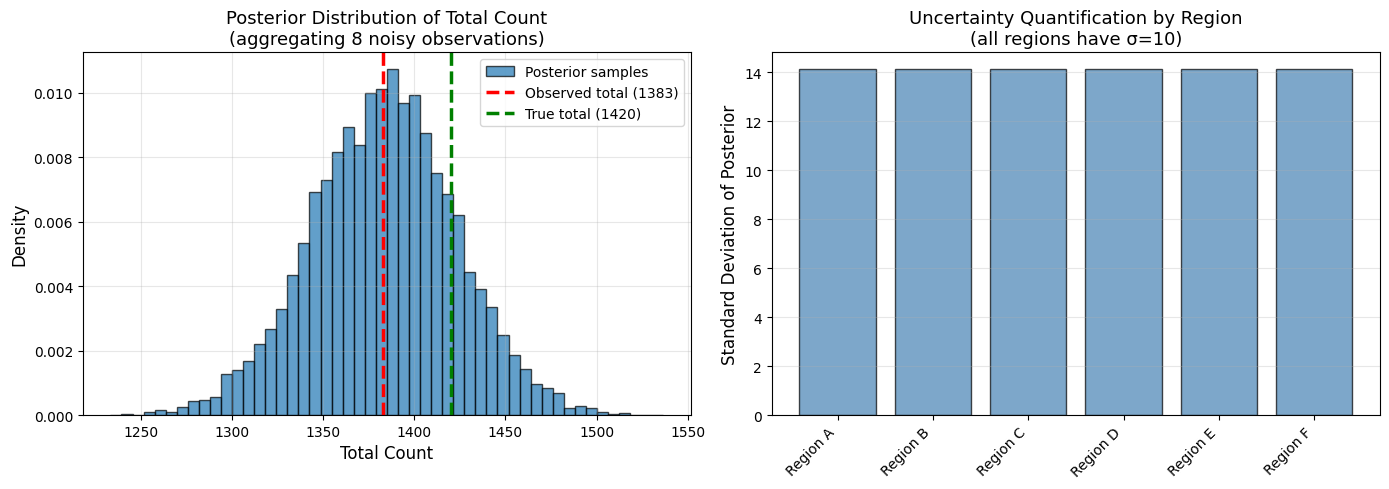

The histogram shows the full posterior distribution of the aggregated count,
accounting for uncertainty in all individual noisy observations.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Histogram of total count samples
ax = axes[0]
ax.hist(total_samples, bins=50, alpha=0.7, edgecolor='black', density=True, label='Posterior samples')
ax.axvline(total_noisy.observed, color='red', linestyle='--', linewidth=2.5, label=f'Observed total ({total_noisy.observed:.0f})')
ax.axvline(true_counts.sum(), color='green', linestyle='--', linewidth=2.5, label=f'True total ({true_counts.sum()})')
ax.set_xlabel('Total Count', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Posterior Distribution of Total Count\n(aggregating 8 noisy observations)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right plot: Uncertainty by region
ax = axes[1]
region_subset = region_names[:6]
uncertainties = []
for nv in noisy_counts[:6]:
    samples = nv.sample_n(5000, seed=42)
    std = samples.std()
    uncertainties.append(std)

x_pos = np.arange(len(region_subset))
ax.bar(x_pos, uncertainties, alpha=0.7, edgecolor='black', color='steelblue')
ax.set_xticks(x_pos)
ax.set_xticklabels(region_subset, rotation=45, ha='right')
ax.set_ylabel('Standard Deviation of Posterior', fontsize=12)
ax.set_title('Uncertainty Quantification by Region\n(all regions have σ=10)', fontsize=13)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"The histogram shows the full posterior distribution of the aggregated count,")
print(f"accounting for uncertainty in all individual noisy observations.")

## Comparing Posterior Width to the Original Noise

When `sample_n` draws from the posterior of a single noisy observation it solves `θ = x_obs − R₁` (a fresh draw) then evaluates `θ + R₂` (another fresh draw), giving:

$$\text{sample} = x_\text{obs} + (R_2 - R_1) \sim \mathcal{N}(x_\text{obs},\ 2\sigma^2)$$

The posterior is therefore **centered on the noisy observation** (not the true value) and **wider** than the original noise by a factor of √2. The plot below overlays these two distributions for Region A.

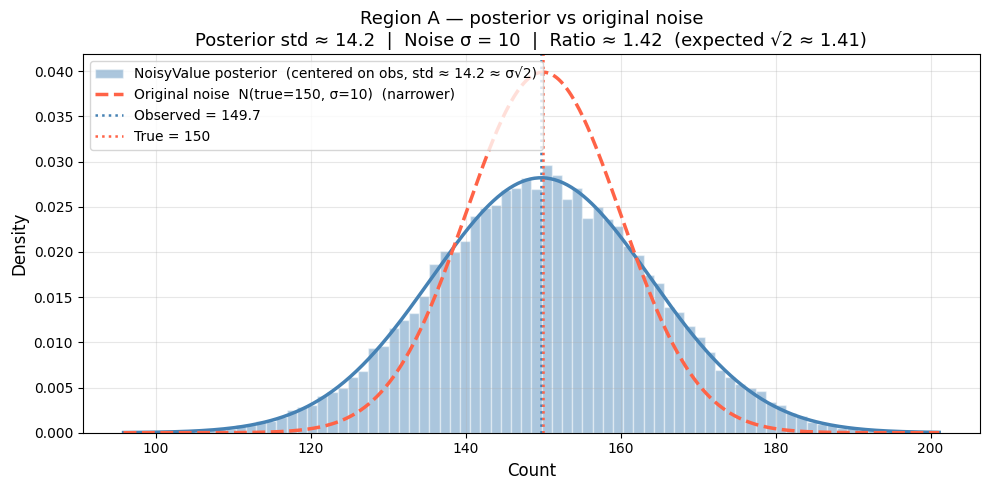

Posterior std:        14.19
Original noise σ:     10.00
Ratio (observed):     1.419
Expected ratio (√2):  1.414


In [10]:
from scipy.stats import norm

# Use Region A for a clean single-component comparison
region_idx = 0
nv_single = noisy_counts[region_idx]
true_val = float(true_counts[region_idx])
obs_val = nv_single.observed

# Sample the NoisyValue posterior (centered on observed, std ≈ σ√2)
single_samples = nv_single.sample_n(20000, seed=42)
sample_std = single_samples.std()

# Build x-axis wide enough for both curves
x = np.linspace(
    min(single_samples.min(), true_val - 4 * noise_scale),
    max(single_samples.max(), true_val + 4 * noise_scale),
    400,
)

fig, ax = plt.subplots(figsize=(10, 5))

# Posterior samples from NoisyValue (centered on observed, wider)
ax.hist(
    single_samples, bins=80, density=True, alpha=0.45,
    color='steelblue', edgecolor='white',
    label=f'NoisyValue posterior  (centered on obs, std ≈ {sample_std:.1f} ≈ σ√2)',
)

# Theoretical posterior curve N(obs, 2σ²)
ax.plot(x, norm.pdf(x, obs_val, noise_scale * np.sqrt(2)),
        color='steelblue', linewidth=2.5, linestyle='-')

# Original noise distribution N(true, σ²) — what was actually added
ax.plot(x, norm.pdf(x, true_val, noise_scale),
        color='tomato', linewidth=2.5, linestyle='--',
        label=f'Original noise  N(true={true_val:.0f}, σ={noise_scale:.0f})  (narrower)')

# Mark the two reference points
ax.axvline(obs_val, color='steelblue', linestyle=':', linewidth=1.8,
           label=f'Observed = {obs_val:.1f}')
ax.axvline(true_val, color='tomato', linestyle=':', linewidth=1.8,
           label=f'True = {true_val:.0f}')

ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(
    f'Region A — posterior vs original noise\n'
    f'Posterior std ≈ {sample_std:.1f}  |  Noise σ = {noise_scale:.0f}  |  '
    f'Ratio ≈ {sample_std / noise_scale:.2f}  (expected √2 ≈ {np.sqrt(2):.2f})',
    fontsize=13,
)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Posterior std:        {sample_std:.2f}")
print(f"Original noise σ:     {noise_scale:.2f}")
print(f"Ratio (observed):     {sample_std / noise_scale:.3f}")
print(f"Expected ratio (√2):  {np.sqrt(2):.3f}")


## Summary

This notebook demonstrated key features of `NoisyValue` for differential privacy analysis:

1. **Noise Addition**: We created `NoisyValue` objects from a true dataset by adding Gaussian noise, simulating differential privacy protection.

2. **Arithmetic Operations**: When we computed aggregates (total, mean), `NoisyValue` correctly tracked how uncertainty compounds through arithmetic operations.

3. **Uncertainty Quantification**: Using `sample_n()`, we sampled from the posterior distribution to quantify uncertainty in our noisy observations.

4. **Visualization**: Histograms and credible intervals give intuitive understanding of the uncertainty around noisy estimates.

**Key Insight**: `NoisyValue` provides a principled way to track noise propagation through multi-step data processing pipelines, ensuring that uncertainty estimates remain valid when combining noisy data sources.